# Chapter 2 Practical 06: Graph-Based Content Recommendation

Learning objectives:
- Build a movie graph from shared content features.
- Visualize movies as nodes and content relationships as edges.
- Compute graph-based similarity using shared neighbors.
- Understand the message-passing idea in simple terms.

Slide connection: graph-based content recommendation, item relationships, graph neighborhoods, and optional graph embeddings.


A content graph connects items when they share features such as genres, directors, or high text similarity.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("data")
if not (DATA_DIR / "movies_chapter2.csv").exists():
    DATA_DIR = Path("../data")
if not (DATA_DIR / "movies_chapter2.csv").exists():
    DATA_DIR = Path("chapter_02_content_based/data")

movies = pd.read_csv(DATA_DIR / "movies_chapter2.csv")
movies.head()


,movie_id,title,genres,director,year,duration_min,rating,family_friendly,description,keywords
0,1,Inception,Sci-Fi|Thriller|Action,Christopher Nolan,2010,148,8.8,0,A thief enters layered dreams to plant an idea...,dreams heist subconscious mind-bending
1,2,Interstellar,Sci-Fi|Adventure|Drama,Christopher Nolan,2014,169,8.7,0,Astronauts travel through a wormhole to find a...,space exploration wormhole survival family
2,3,Titanic,Romance|Drama,James Cameron,1997,195,7.9,0,A young couple from different social classes f...,romance ship tragedy historical
3,4,The Matrix,Sci-Fi|Action,The Wachowskis,1999,136,8.7,0,A hacker discovers that reality is a simulated...,simulation hacker reality action cyberpunk
4,5,Toy Story,Animation|Adventure|Comedy|Family,John Lasseter,1995,81,8.3,1,A cowboy doll feels threatened when a space ra...,toys friendship family adventure


Build a graph where nodes are movies and edges mean shared genre or same director.


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

G = nx.Graph()
for _, row in movies.iterrows():
    G.add_node(row["title"], genres=set(row["genres"].split("|")), director=row["director"], rating=row["rating"])

for a, b in combinations(movies["title"], 2):
    a_data, b_data = G.nodes[a], G.nodes[b]
    shared_genres = a_data["genres"] & b_data["genres"]
    same_director = a_data["director"] == b_data["director"]
    if shared_genres or same_director:
        weight = len(shared_genres) + (1.5 if same_director else 0)
        reason = ", ".join(sorted(shared_genres))
        if same_director:
            reason = (reason + ", " if reason else "") + "same director"
        G.add_edge(a, b, weight=weight, reason=reason)

print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())
list(G.edges(data=True))[:8]


nodes: 12 edges: 35


[('Inception',
  'Interstellar',
  {'weight': 2.5, 'reason': 'Sci-Fi, same director'}),
 ('Inception', 'The Matrix', {'weight': 2, 'reason': 'Action, Sci-Fi'}),
 ('Inception',
  'The Dark Knight',
  {'weight': 2.5, 'reason': 'Action, same director'}),
 ('Inception', 'The Martian', {'weight': 1, 'reason': 'Sci-Fi'}),
 ('Inception', 'Gravity', {'weight': 2, 'reason': 'Sci-Fi, Thriller'}),
 ('Interstellar', 'Titanic', {'weight': 1, 'reason': 'Drama'}),
 ('Interstellar', 'The Matrix', {'weight': 1, 'reason': 'Sci-Fi'}),
 ('Interstellar', 'Toy Story', {'weight': 1, 'reason': 'Adventure'})]

Visualize the graph. Thicker edges mean stronger content overlap.


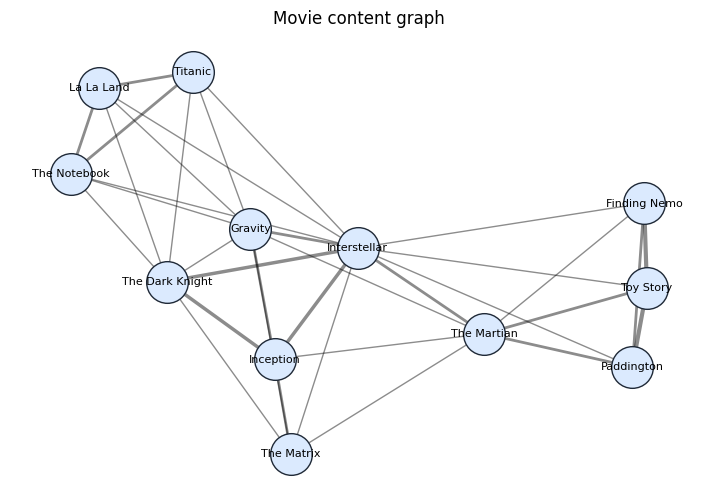

In [3]:
plt.figure(figsize=(9, 6))
pos = nx.spring_layout(G, seed=7)
edge_widths = [G[u][v]["weight"] for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=900, node_color="#dbeafe", edgecolors="#1f2937")
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.45)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Movie content graph")
plt.axis("off")
plt.show()


A simple graph similarity score can combine direct edge strength and shared neighbors.


In [4]:
def graph_similarity(source, target):
    direct = G[source][target]["weight"] if G.has_edge(source, target) else 0
    common = len(list(nx.common_neighbors(G, source, target)))
    return direct + 0.5 * common

def graph_recommend(title, n=5):
    rows = []
    for other in G.nodes:
        if other == title:
            continue
        rows.append({
            "input_movie": title,
            "recommended_movie": other,
            "graph_score": graph_similarity(title, other),
            "edge_reason": G[title][other]["reason"] if G.has_edge(title, other) else "shared neighbors only",
        })
    return pd.DataFrame(rows).sort_values("graph_score", ascending=False).head(n)

graph_recommend("Interstellar")


,input_movie,recommended_movie,graph_score,edge_reason
5,Interstellar,The Dark Knight,5.5,"Drama, same director"
9,Interstellar,Gravity,5.5,"Drama, Sci-Fi"
6,Interstellar,The Martian,5.0,"Adventure, Sci-Fi"
0,Interstellar,Inception,4.5,"Sci-Fi, same director"
1,Interstellar,Titanic,3.0,Drama


Centrality can identify well-connected items. This is not personalization by itself, but it helps explain graph structure.


In [5]:
centrality = pd.Series(nx.degree_centrality(G), name="degree_centrality").sort_values(ascending=False)
centrality.head(8).round(3)


Interstellar       1.000
Gravity            0.727
The Dark Knight    0.636
The Martian        0.636
Inception          0.455
Titanic            0.455
The Matrix         0.455
The Notebook       0.455
Name: degree_centrality, dtype: float64

Optional node embeddings can be useful, but the notebook remains runnable without them.


In [6]:
try:
    from node2vec import Node2Vec
    node2vec = Node2Vec(G, dimensions=8, walk_length=5, num_walks=30, workers=1, quiet=True, seed=7)
    model = node2vec.fit(window=3, min_count=1, batch_words=16)
    print("Node2Vec embeddings learned.")
    print(model.wv.most_similar("Interstellar", topn=5))
except Exception as exc:
    print("Optional Node2Vec is not available. The NetworkX graph recommendation above is the fallback.")
    print(type(exc).__name__, str(exc)[:160])


Optional Node2Vec is not available. The NetworkX graph recommendation above is the fallback.
ModuleNotFoundError No module named 'node2vec'


Message passing idea:

Each movie can receive information from its neighbors. After one step, a movie knows about directly connected movies. After two steps, it also receives signals from neighbors of neighbors. Graph neural networks formalize this idea with learned transformations.

## What did we learn?

- Graphs represent relationships between items, not only feature rows.
- Shared genres and directors can create interpretable edges.
- A simple NetworkX fallback is enough to teach graph-based recommendation before advanced GNNs.

Exercises:
1. Add edges for high TF-IDF similarity and compare the graph.
2. Recommend movies from a two-item user profile by averaging graph scores.
